In [1]:
import dnnlpy
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

dnnlpy.set_matplotlib_format("highdpi")
print("PyTorch version:", torch.__version__)



PyTorch version: 2.13.0+cpu


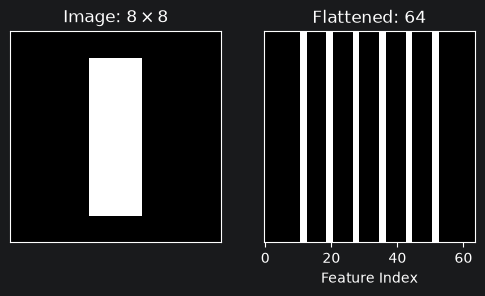

MNIST input layer: 401,408 parameters.
ImageNet input layer: 77,070,336 parameters.


In [4]:

"""
    图像不只是一个向量
"""
image = torch.zeros(8, 8)
image[1:7, 3:5] = 1.0

flattened = image.view(1, -1)
flattened = flattened.repeat(image.numel(), 1)

fig = plt.figure(1, figsize=(6, 3))
ax1 = fig.add_subplot(1, 2, 1)
ax1.imshow(image, cmap='gray', vmin=0, vmax=1)
ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_title(r'Image: $8 \times 8$')
ax2 = fig.add_subplot(1, 2, 2)
ax2.imshow(flattened, cmap='gray', vmin=0, vmax=1)
ax2.set_aspect('equal')
ax2.set_yticks([])
ax2.set_xlabel('Feature Index')
ax2.set_title('Flattened: 64')
plt.show()

mlp1 = nn.Linear(28 * 28, 512, bias=False)
mlp2 = nn.Linear(3 * 224 * 224, 512, bias=False)
params1 = dnnlpy.count_params(mlp1)
params2 = dnnlpy.count_params(mlp2)

print(f'MNIST input layer: {params1:,} parameters.')
print(f'ImageNet input layer: {params2:,} parameters.')


In [5]:
"""
图像中的模式通常时局部的
    - 视觉特征具有明其心那的层次结构,但底层的信息来自一个小小的邻域
    - CNN 采用的是局部链接,只观察局部的部分不是全部
有一个可用的假设(归纳偏置)
    - 附近的像素通常比相距很远的像素更加直接关联
"""

image_size = 8
kernel_size = 3

full_connections = image_size * image_size
local_connections = kernel_size * kernel_size

print("Connecting used  by one n connected unit:", full_connections)
print("Connecting to by one 3X3 unit", local_connections)

Connecting used  by one n connected unit: 64
Connecting to by one 3X3 unit 9


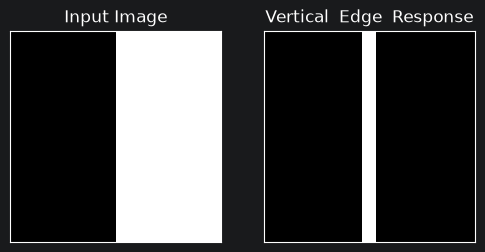

In [7]:
"""
同一个模式可以出现在任何位置
    - 每次只计算一个局部区域
    - 让同一种局部检测器在整张图片上重复使用(权重共享)
"""

image = torch.zeros(1, 1, 32, 32)
image[..., 16:] = 1.0

kernel = torch.tensor([
    [-1.0, 0.0, 1.0],
    [-1.0, 0.0, 1.0],
    [-1.0, 0.0, 1.0],
]).view(1, 1, 3, 3)

response = F.conv2d(image, kernel)

fig = plt.figure(2, figsize=(6, 3))
ax1 = fig.add_subplot(1, 2, 1)
ax1.imshow(image[0, 0], cmap='gray')
ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_title("Input Image")
ax2 = fig.add_subplot(1, 2, 2)
ax2.imshow(response[0, 0], cmap='gray')
ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_title("Vertical  Edge  Response")
plt.show()

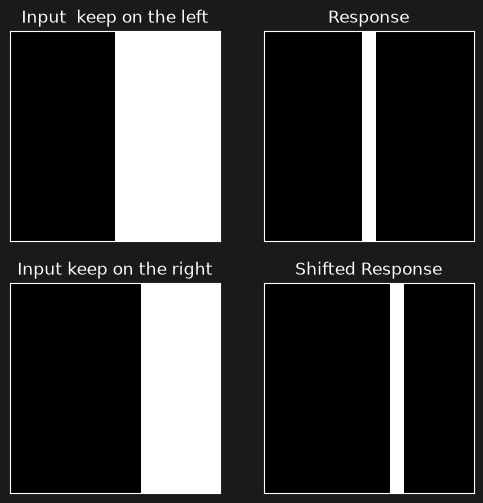

In [8]:
"""
从权重共享到平移等变
    平移等变性: 输入平移后,特征图也相应平移
    平移不变性: 输入平移后,最终输出保持不变
"""

image_left = torch.zeros(1, 1, 32, 32)
image_left[..., 16:] = 1.0

image_right = torch.zeros(1, 1, 32, 32)
image_right[..., 20:] = 1.0

response_left = F.conv2d(image_left, kernel)
response_right = F.conv2d(image_right, kernel)

fig = plt.figure(3, figsize=(6, 6))
ax1 = fig.add_subplot(2, 2, 1)
ax1.imshow(image_left[0, 0], cmap='gray')
ax1.set_title("Input  keep on the left")
ax2 = fig.add_subplot(2, 2, 2)
ax2.imshow(response_left[0, 0], cmap='gray')
ax2.set_title("Response")
ax3 = fig.add_subplot(2, 2, 3)
ax3.imshow(image_right[0, 0], cmap='gray')
ax3.set_title("Input keep on the right")
ax4 = fig.add_subplot(2, 2, 4)
ax4.imshow(response_right[0, 0], cmap='gray')
ax4.set_title("Shifted Response")

for  ax in (ax1,ax2,ax3,ax4):
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()



In [9]:
"""
    卷积如何减少参数
        - 全连接层为每个输出神经元和每个输出像素之间都保存着独立的关系
        - 卷积层只是学习少量的局部权重,并把这些权重共享到整张图像
"""

linear =  nn.Linear(3*224*224, 64, bias=False)
conv2d = nn.Conv2d(3,64,kernel_size=3,bias=False)

linear_params =  dnnlpy.count_params(linear)
conv2d_params =  dnnlpy.count_params(conv2d)

print(f"Linear  layer: {linear_params:,} parameters.")
print(f"Conv2d layer: {conv2d_params:,} parameters.")

Linear  layer: 9,633,792 parameters.
Conv2d layer: 1,728 parameters.
